# Lag-Llama MindSpore 论文复现 Notebook

本 Notebook 用于课程作业提交，记录 MindSpore 版 Lag-Llama 的复现流程、运行命令和最终实验结果读取方式。

本项目对应论文：**Lag-Llama: Towards Foundation Models for Probabilistic Time Series Forecasting**。

注意：Notebook 中的长时间训练建议在 ModelArts 终端执行；Notebook 主要用于环境检查、流程展示、结果读取和报告材料整理。

## 1. 环境检查

检查当前 Python 环境、项目根目录和 MindSpore 后端。若本地无法导入 MindSpore，请在 ModelArts 的 MindSpore Notebook/Console 中运行。

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Python:", sys.version)
print("Project root:", PROJECT_ROOT)

try:
    import mindspore as ms
    print("MindSpore:", ms.__version__)
    print("device_target:", ms.get_context("device_target"))
except Exception as exc:
    print("MindSpore import/check failed:", repr(exc))
    print("请切换到 ModelArts MindSpore 环境运行训练。")

Python: 3.12.7 | packaged by Anaconda, Inc. | (main, Oct  4 2024, 08:22:19) [Clang 14.0.6 ]
Project root: /Users/wangyitong/BUAA/AI/mindspore_lag_llama
MindSpore import/check failed: ModuleNotFoundError("No module named 'mindspore'")
请切换到 ModelArts MindSpore 环境运行训练。


## 2. 复现范围

本次复现采用资源受限设置：

- 10 个论文真实数据集用于预训练；
- 3 个未见真实数据集用于 downstream zero-shot 和 fine-tuning；
- 实现 Student-T 概率预测、lag 特征、time features、frequency augmentation、early stopping；
- 补充 AutoETS、DynOptTheta、DeepAR、PatchTST 代表性基线；
- 使用 CRPS / mean weighted quantile loss、sample CRPS、MAE、MSE 作为指标。

该实验不是论文完整 27 数据集和全部基线的严格复现，而是课程预算下的核心技术路线复现。

## 3. 冒烟测试

冒烟测试只用于确认代码、模型形状和 MindSpore 训练图能跑通，不作为论文复现结果。

In [2]:
# 在 ModelArts 终端或 Notebook 中运行：
# !bash scripts/run_smoke.sh

# 期望输出：
# results/metrics_smoke.json
# results/train_history_smoke.json
# results/figures/forecast_smoke.png

## 4. 数据准备

主实验数据由脚本自动下载/转换生成。`data/` 目录默认不提交完整原始数据，详见 `data/README.md`。

生成 paper10 数据集：

In [3]:
# 在项目根目录运行：
# !python scripts/prepare_paper10_datasets.py

# 生成目录：
# data/paper10_pretrain/
# data/paper10_downstream/

### 预训练数据集

```text
ETTh1, ETTh2, ETTm1,
electricity_hourly, solar_10_minutes, traffic,
kdd_cup_2018_without_missing, sunspot_without_missing,
australian_electricity_demand, london_smart_meters_without_missing
```

### 下游未见数据集

```text
ETTm2, exchange_rate, weather
```

## 5. 主实验运行命令

完整主流程包括：数据准备、预训练、zero-shot 评估、fine-tuning、fine-tuned 评估、统计基线、深度基线和图像汇总。

建议在 ModelArts 终端执行，避免 Notebook 断连影响训练。

In [4]:
# 主实验命令：
# !bash scripts/run_paper10_budget.sh

# 本次实验主要配置：
# PRETRAIN_EPOCHS=150
# FINETUNE_EPOCHS=20
# MAX_TRAIN_BATCHES=256
# MAX_VAL_BATCHES=256
# EVAL_SAMPLES=10

## 6. 下游评估和基线补跑

如果已经有预训练 checkpoint，可以只重跑 downstream 评估和基线。

In [5]:
# !bash scripts/run_paper10_downstreams.sh

# 默认读取：
# results/checkpoints/lag_llama_paper10_pretrain_best.ckpt

## 7. samples=30 CRPS 稳定性复核

论文使用更多 empirical samples 评估概率预测。本实验主结果使用 `num_samples=10`，并额外使用 `num_samples=30` 对 fine-tuned 模型进行稳定性复核。

为控制 CPU 评估时间，补充实验设置 `max_eval_windows=64`。

In [6]:
# ETTm2 samples=30 评估示例：
# !python -m src.evaluate #   --dataset csv #   --data_path data/paper10_downstream/ETTm2.csv #   --target_column OT #   --time_column date #   --checkpoint_path results/checkpoints/lag_llama_paper10_ettm2_finetune_best.ckpt #   --output_checkpoint lag_llama_paper10_ettm2_finetune_best.ckpt #   --metrics_file metrics_paper10_finetuned_ettm2_samples30.json #   --figure_file forecast_paper10_finetuned_ettm2_samples30.png #   --device_target CPU #   --num_samples 30 #   --batch_size 8 #   --window_stride 96 #   --max_eval_windows 64 #   --log_every 1

## 8. 读取最终结果

下面的代码会读取 `results/` 中的 JSON 指标并生成表格。若本地代码目录没有结果，请先将从 ModelArts 下载的 `results/` 放回项目根目录。

In [7]:
import json
from pathlib import Path
import pandas as pd

RESULTS_DIR = PROJECT_ROOT / "results"

items = [
    ("ETTm2", "zero-shot", "metrics_paper10_zero_shot_ettm2.json"),
    ("ETTm2", "fine-tuned", "metrics_paper10_finetuned_ettm2.json"),
    ("exchange_rate", "zero-shot", "metrics_paper10_zero_shot_exchange_rate.json"),
    ("exchange_rate", "fine-tuned", "metrics_paper10_finetuned_exchange_rate.json"),
    ("weather", "zero-shot", "metrics_paper10_zero_shot_weather.json"),
    ("weather", "fine-tuned", "metrics_paper10_finetuned_weather.json"),
]

rows = []
for dataset, setting, filename in items:
    path = RESULTS_DIR / filename
    if not path.exists():
        print("missing", path)
        continue
    payload = json.load(open(path, encoding="utf-8"))
    m = payload["metrics"]
    rows.append({
        "dataset": dataset,
        "setting": setting,
        "MAE": m.get("model_mae"),
        "MSE": m.get("model_mse"),
        "CRPS/mean_wQL": m.get("model_crps"),
        "sample_CRPS": m.get("model_sample_crps"),
        "best_lightweight_baseline": m.get("best_classical_baseline"),
        "baseline_MAE": m.get("best_classical_baseline_mae"),
        "baseline_MSE": m.get("best_classical_baseline_mse"),
    })

main_df = pd.DataFrame(rows)
main_df

,dataset,setting,MAE,MSE,CRPS/mean_wQL,sample_CRPS,best_lightweight_baseline,baseline_MAE,baseline_MSE
0,ETTm2,zero-shot,3.317152,23.199116,0.093502,2.578686,moving_average,2.413722,9.667790
1,ETTm2,fine-tuned,1.128054,3.118190,0.038123,1.065878,moving_average,2.413722,9.667790
2,exchange_rate,zero-shot,0.046402,0.004707,0.062596,0.059578,last_value,0.015768,0.000514
3,exchange_rate,fine-tuned,0.018714,0.000692,0.020387,0.019031,last_value,0.015768,0.000514
4,weather,zero-shot,1.315473,16.400307,1.383824,1.740846,moving_average,1.921869,15.580446
5,weather,fine-tuned,1.285060,16.468693,1.366692,1.785508,moving_average,1.921869,15.580446


## 9. 读取论文代表性基线结果

本实验补充运行了 AutoETS、DynOptTheta 两个统计基线，以及 DeepAR、PatchTST 两个轻量 MindSpore 深度基线。

In [8]:
baseline_rows = []
for dataset in ["ettm2", "exchange_rate", "weather"]:
    stat_path = RESULTS_DIR / f"paper_baselines_{dataset}.json"
    if stat_path.exists():
        payload = json.load(open(stat_path, encoding="utf-8"))
        for name, entry in payload.get("paper_baseline_metrics", {}).items():
            if isinstance(entry, dict) and entry.get("status") == "ok":
                baseline_rows.append({
                    "dataset": dataset,
                    "baseline": name,
                    "type": "statistical",
                    "MAE": entry.get("mae"),
                    "MSE": entry.get("mse"),
                })

    deep_path = RESULTS_DIR / f"paper_deep_baselines_{dataset}.json"
    if deep_path.exists():
        payload = json.load(open(deep_path, encoding="utf-8"))
        for name, entry in payload.get("paper_deep_baseline_metrics", {}).items():
            if isinstance(entry, dict) and entry.get("status") == "ok":
                baseline_rows.append({
                    "dataset": dataset,
                    "baseline": name,
                    "type": "deep",
                    "MAE": entry.get("mae"),
                    "MSE": entry.get("mse"),
                })

baseline_df = pd.DataFrame(baseline_rows)
baseline_df

,dataset,baseline,type,MAE,MSE
0,ettm2,AutoETS,statistical,4.269660,33.352642
1,ettm2,DynOptTheta,statistical,2.044577,7.843102
2,ettm2,DeepAR,deep,6.340917,56.059799
3,ettm2,PatchTST,deep,6.341789,56.953480
4,exchange_rate,AutoETS,statistical,0.015979,0.000519
5,exchange_rate,DynOptTheta,statistical,0.015850,0.000517
6,exchange_rate,DeepAR,deep,0.074317,0.007465
7,exchange_rate,PatchTST,deep,0.073752,0.008536
8,weather,AutoETS,statistical,2.197174,15.192787
9,weather,DynOptTheta,statistical,2.054395,15.628211


## 10. samples=30 补充结果

该结果用于验证概率预测指标稳定性，不直接替代主实验，因为它限制了 `max_eval_windows=64`。

In [9]:
sample30_items = [
    ("ETTm2", "metrics_paper10_finetuned_ettm2_samples30.json"),
    ("exchange_rate", "metrics_paper10_finetuned_exchange_rate_samples30.json"),
    ("weather", "metrics_paper10_finetuned_weather_samples30.json"),
]

rows = []
for dataset, filename in sample30_items:
    path = RESULTS_DIR / filename
    if not path.exists():
        print("missing", path)
        continue
    payload = json.load(open(path, encoding="utf-8"))
    m = payload["metrics"]
    cfg = payload["config"]
    rows.append({
        "dataset": dataset,
        "num_samples": cfg.get("num_samples"),
        "max_eval_windows": cfg.get("max_eval_windows"),
        "MAE": m.get("model_mae"),
        "MSE": m.get("model_mse"),
        "CRPS/mean_wQL": m.get("model_crps"),
        "sample_CRPS": m.get("model_sample_crps"),
    })

sample30_df = pd.DataFrame(rows)
sample30_df

,dataset,num_samples,max_eval_windows,MAE,MSE,CRPS/mean_wQL,sample_CRPS
0,ETTm2,30,64,0.979162,1.884095,0.032232,0.866643
1,exchange_rate,30,64,0.018714,0.000692,0.020331,0.017970
2,weather,30,64,1.285060,16.468693,1.366803,1.700580


## 11. 展示关键图像

这些图可直接用于报告或 PPT。

/Users/wangyitong/BUAA/AI/mindspore_lag_llama/results/figures/paper10_downstream_mae_comparison.png


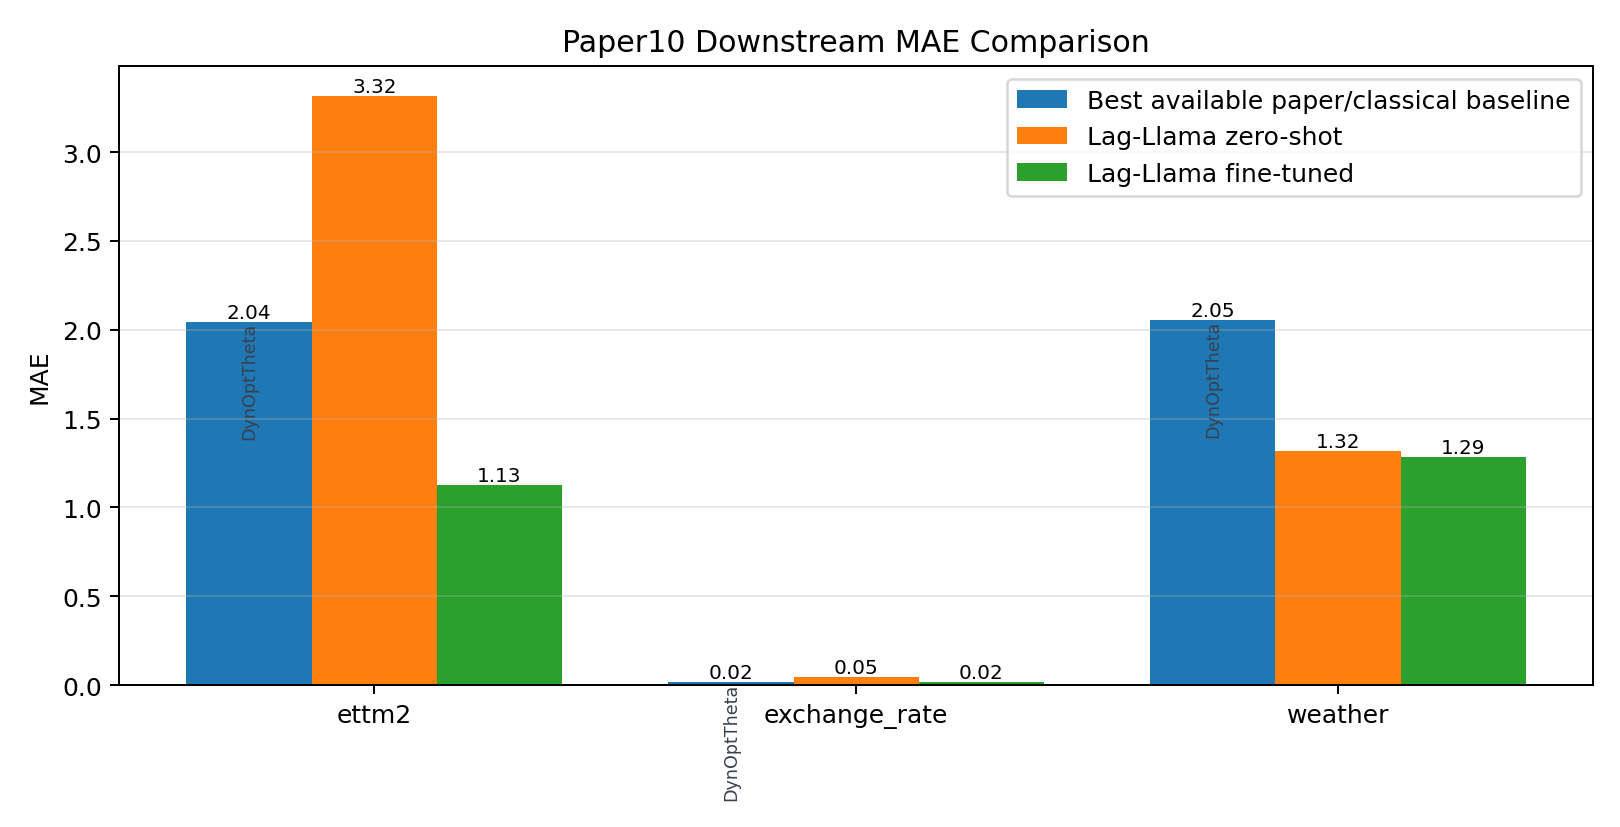

/Users/wangyitong/BUAA/AI/mindspore_lag_llama/results/figures/paper10_downstream_mse_comparison.png


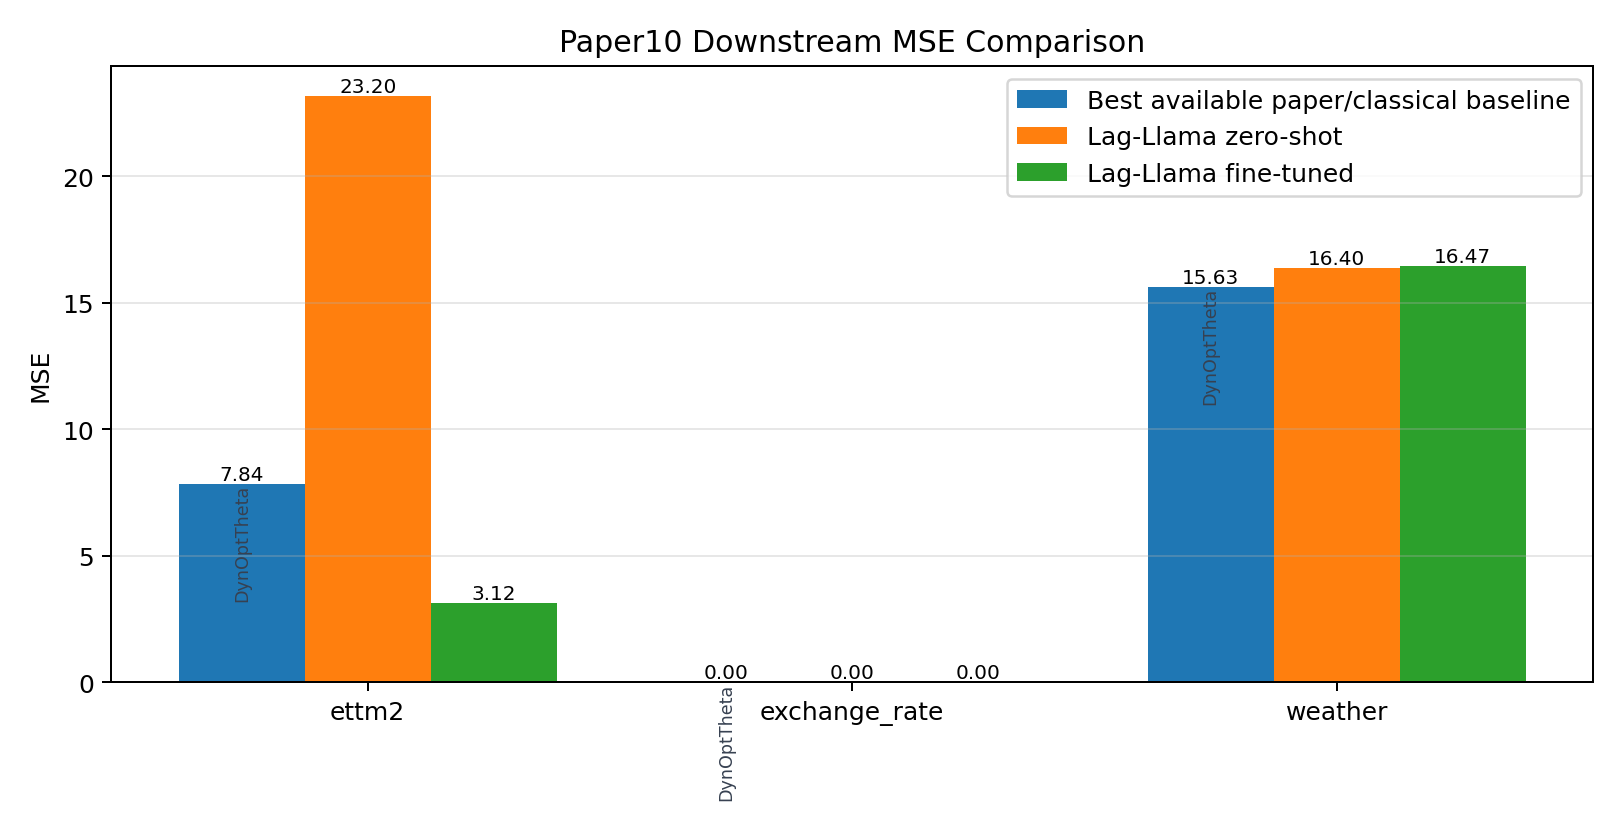

/Users/wangyitong/BUAA/AI/mindspore_lag_llama/results/figures/forecast_paper10_finetuned_ettm2.png


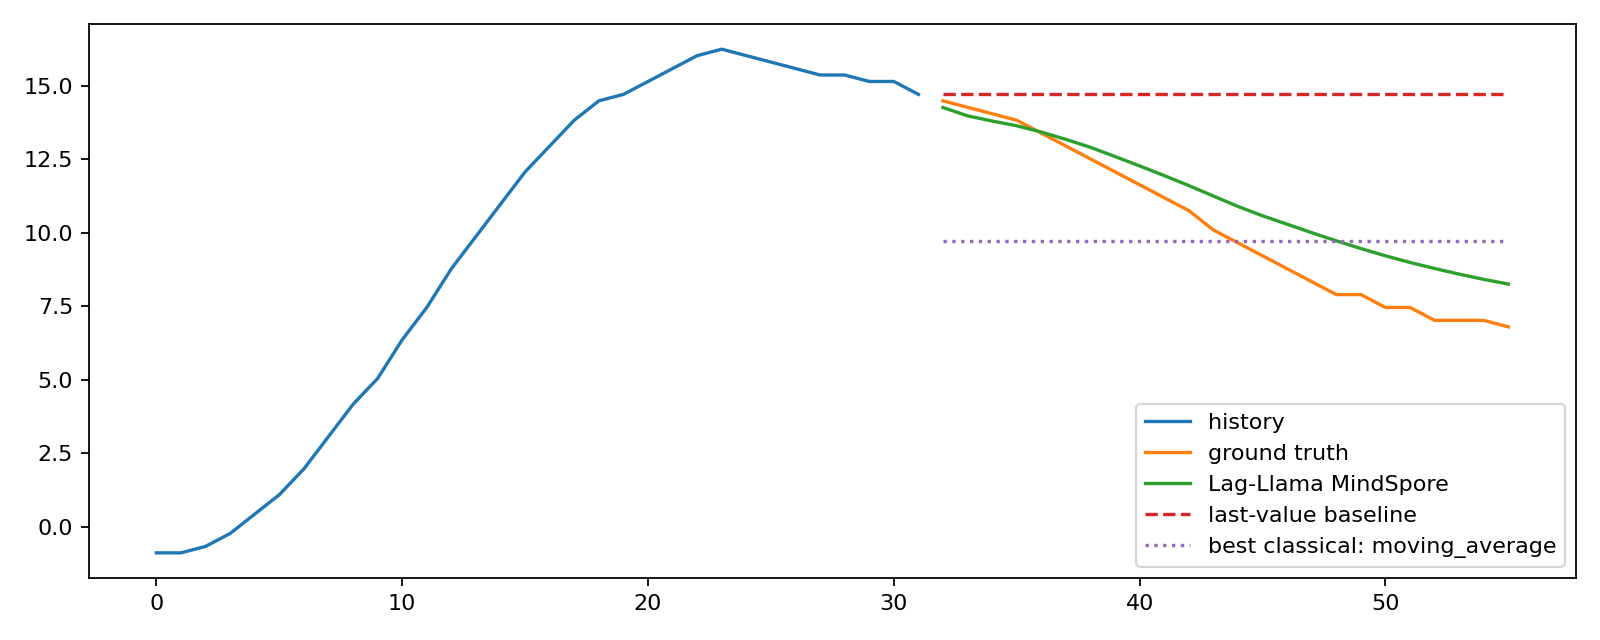

/Users/wangyitong/BUAA/AI/mindspore_lag_llama/results/figures/forecast_paper10_finetuned_exchange_rate.png


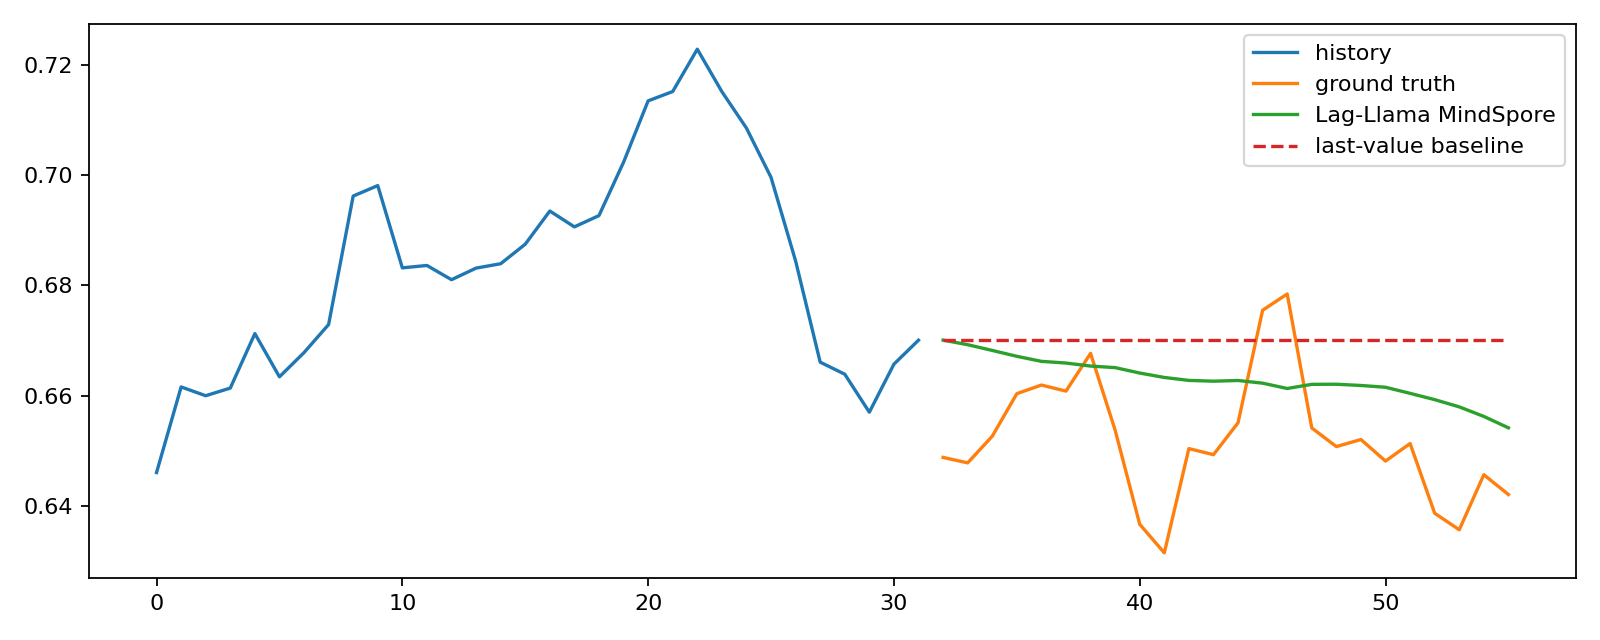

/Users/wangyitong/BUAA/AI/mindspore_lag_llama/results/figures/forecast_paper10_finetuned_weather.png


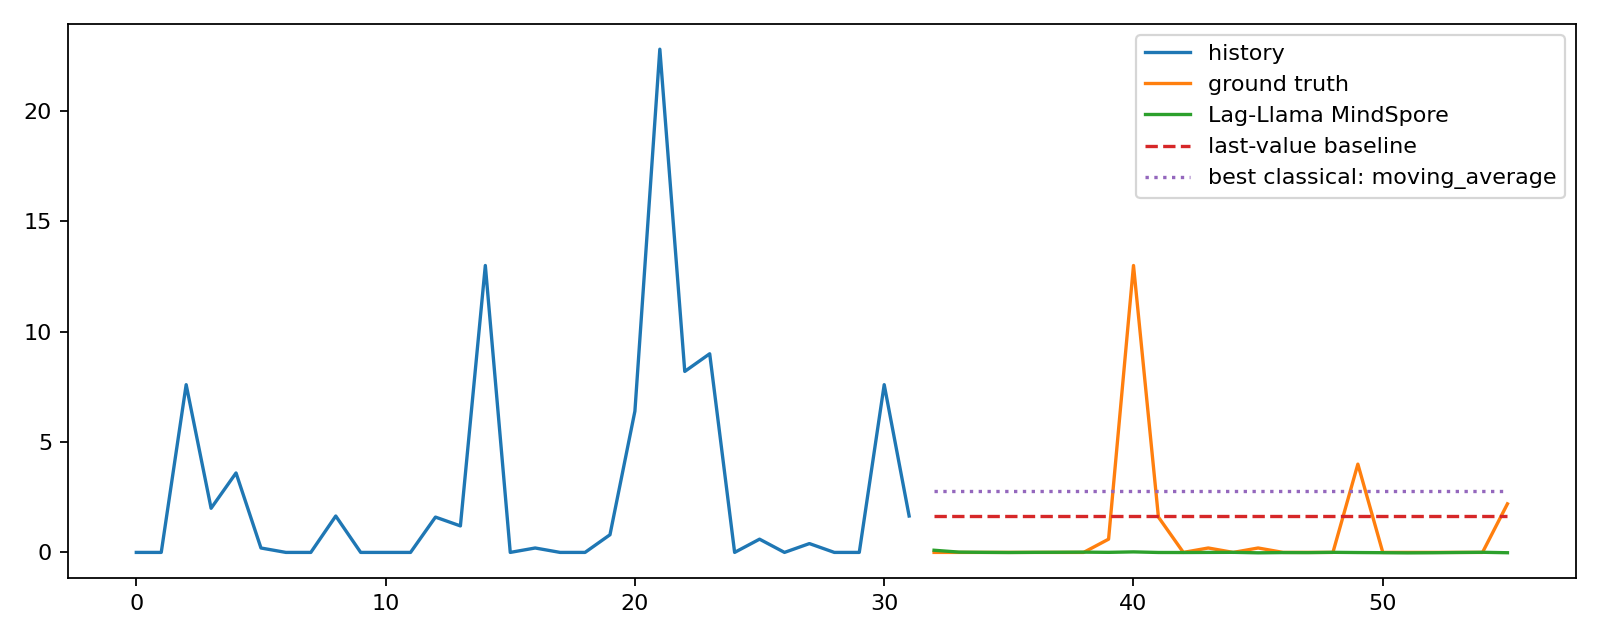

In [10]:
from IPython.display import Image, display

figure_files = [
    "paper10_downstream_mae_comparison.png",
    "paper10_downstream_mse_comparison.png",
    "forecast_paper10_finetuned_ettm2.png",
    "forecast_paper10_finetuned_exchange_rate.png",
    "forecast_paper10_finetuned_weather.png",
]

for name in figure_files:
    path = RESULTS_DIR / "figures" / name
    print(path)
    if path.exists():
        display(Image(filename=str(path)))
    else:
        print("missing", path)

## 12. 实验结论

本次资源受限复现实验得到以下结论：

1. 多数据集预训练后的 Lag-Llama 在未见数据集上具备一定 zero-shot 能力。
2. Fine-tuning 后，ETTm2 和 weather 上的预测效果显著提升，并在 MAE 指标上优于代表性统计基线。
3. exchange_rate 上 fine-tuned 模型明显优于 zero-shot，但仍略弱于 last-value / DynOptTheta，说明随机游走型序列对简单基线更友好。
4. samples=30 补充实验表明概率预测指标较稳定，CRPS 结论与主实验一致。
5. 由于训练数据规模、基线完整性、采样数量和评估窗口受限，本实验不能等同于论文完整 Table 1 复现，但复现了 Lag-Llama 的主要技术路线和实验趋势。

## 13. 结果打包

ModelArts 运行结束后，建议下载轻量结果包：

In [11]:
# 在 /home/ma-user/work 下执行：
# !zip -r lag_llama_final_report_assets_light.zip #   mindspore_lag_llama/results/*.json #   mindspore_lag_llama/results/figures #   mindspore_lag_llama/results/train_history_paper10_pretrain.json